
Dataset Loaded Successfully
Training Data Shape: (125973, 43)
Testing Data Shape: (22544, 43)
 duration protocol_type  service flag  src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  num_failed_logins  logged_in  num_compromised  root_shell  su_attempted  num_root  num_file_creations  num_shells  num_access_files  num_outbound_cmds  is_host_login  is_guest_login  count  srv_count  serror_rate  srv_serror_rate  rerror_rate  srv_rerror_rate  same_srv_rate  diff_srv_rate  srv_diff_host_rate  dst_host_count  dst_host_srv_count  dst_host_same_srv_rate  dst_host_diff_srv_rate  dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate  dst_host_srv_rerror_rate  attack  level
        0           tcp ftp_data   SF        491          0     0               0       0    0                  0          0                0           0             0         0                   0           0                 0                  0

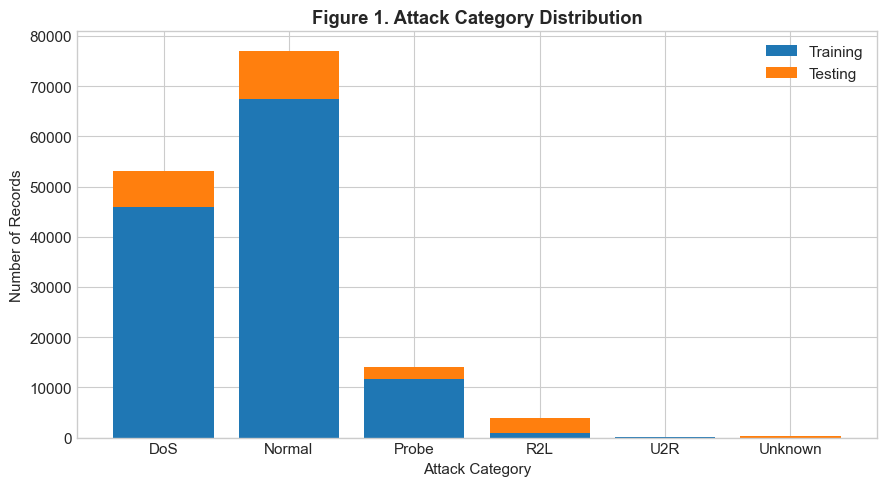


Table 3: Statistical Analysis of the Dataset
         Attribute       Mean  Median  Standard Deviation      Maximum  Minimum
          duration   287.1447     0.0           2604.5153      42908.0      0.0
         src_bytes 45566.7430    44.0        5870331.1819 1379963888.0      0.0
         dst_bytes 19779.1144     0.0        4021269.1514 1309937401.0      0.0
    wrong_fragment     0.0227     0.0              0.2535          3.0      0.0
            urgent     0.0001     0.0              0.0144          3.0      0.0
               hot     0.2044     0.0              2.1500         77.0      0.0
 num_failed_logins     0.0012     0.0              0.0452          5.0      0.0
             count    84.1076    14.0            114.5086        511.0      0.0
         srv_count    27.7379     8.0             72.6358        511.0      0.0
       serror_rate     0.2845     0.0              0.4465          1.0      0.0
     same_srv_rate     0.6609     1.0              0.4396          1.0    

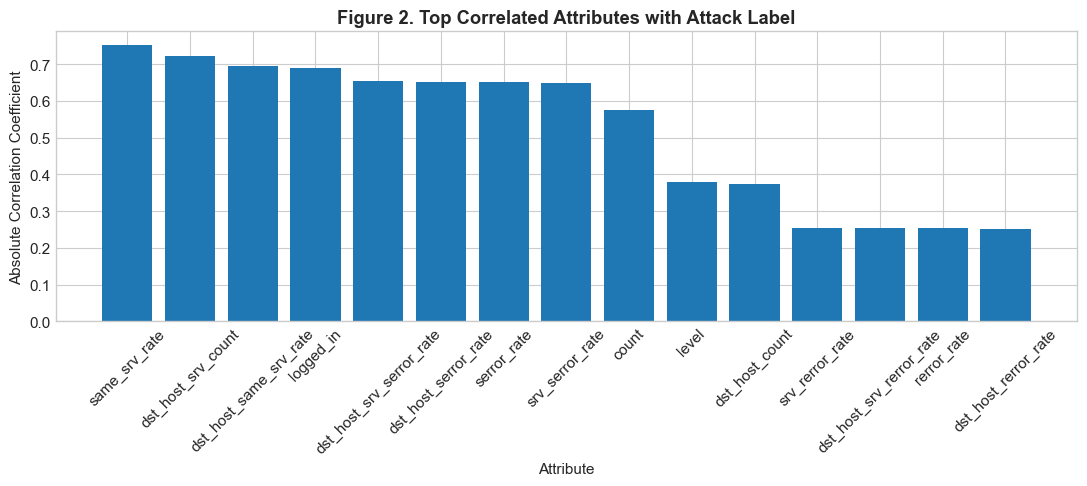


Prepare Data for Machine Learning
Target Classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R', 'Unknown']

Table 5: Feature Information
                Item                           Description
             Dataset                               NSL-KDD
       Training file                         KDDTrain+.txt
        Testing file                          KDDTest+.txt
   Original features           41 network traffic features
Categorical features          protocol_type, service, flag
      Target classes DoS, Normal, Probe, R2L, U2R, Unknown
        Problem type            Multi-class classification
Saved table: NSL_KDD_report_outputs\Table_5_Feature_Information.csv

Table 6: Machine Learning Model Comparison


In [ ]:
# =========================================================
# Network Intrusion Detection System using NSL-KDD Dataset
# Same Report Style as the Provided Code
# Dataset Files:
# KDDTrain+.txt
# KDDTest+.txt
# =========================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from docx import Document
from docx.shared import Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

warnings.filterwarnings("ignore")

# =========================================================
# 1. General Settings
# =========================================================
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

OUTPUT_DIR = "NSL_KDD_report_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_FILE = "KDDTrain+.txt"
TEST_FILE = "KDDTest+.txt"

# If your computer is slow, set this to True.
# إذا كان الجهاز بطيء، خليه True
USE_SMALL_SAMPLE_FOR_SVM = False
SVM_SAMPLE_SIZE = 20000

# =========================================================
# 2. Word Report Settings
# =========================================================
word_doc = Document()

def set_cell_shading(cell, fill_color):
    tc_pr = cell._tc.get_or_add_tcPr()
    shd = OxmlElement("w:shd")
    shd.set(qn("w:fill"), fill_color)
    tc_pr.append(shd)

def set_cell_text(cell, text, bold=False):
    cell.text = ""
    p = cell.paragraphs[0]
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    run = p.add_run(str(text))
    run.bold = bold
    run.font.size = Pt(9)
    cell.vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER

def add_title_page():
    title = word_doc.add_heading("Network Intrusion Detection Using Machine Learning", level=0)
    title.alignment = WD_ALIGN_PARAGRAPH.CENTER

    p = word_doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    run = p.add_run("Generated Tables from Python Machine Learning Experiment")
    run.bold = True
    run.font.size = Pt(12)

    word_doc.add_paragraph("")
    word_doc.add_paragraph(
        "This report uses the NSL-KDD dataset for intrusion detection. "
        "The file KDDTrain+.txt is used for training and KDDTest+.txt is used for testing. "
        "The goal is to classify network traffic into Normal, DoS, Probe, R2L, and U2R classes."
    )

def add_dataframe_to_word(title, df):
    word_doc.add_heading(title, level=2)

    if df.empty:
        word_doc.add_paragraph("No data available.")
        return

    table = word_doc.add_table(rows=1, cols=len(df.columns))
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    table.style = "Table Grid"

    header_cells = table.rows[0].cells
    for i, col in enumerate(df.columns):
        set_cell_text(header_cells[i], col, bold=True)
        set_cell_shading(header_cells[i], "D9EAF7")

    for _, row in df.iterrows():
        cells = table.add_row().cells
        for i, value in enumerate(row):
            if isinstance(value, float):
                value = round(value, 4)
            set_cell_text(cells[i], value)

    word_doc.add_paragraph("")

def save_word_report(filename="NSL_KDD_ML_Tables_Report.docx"):
    path = os.path.join(OUTPUT_DIR, filename)
    word_doc.save(path)
    print(f"Word report saved successfully: {path}")

add_title_page()

# =========================================================
# 3. Helper Functions
# =========================================================
def save_table(df, name):
    path = os.path.join(OUTPUT_DIR, name)
    df.to_csv(path, index=False)
    print(f"Saved table: {path}")

def classification_scores(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    return acc, pre, rec, f1

def print_section(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

def plot_confusion_matrix(y_true, y_pred, class_names, title, filename):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(9, 6))
    plt.imshow(cm)
    plt.title(title, fontweight="bold")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
    plt.yticks(np.arange(len(class_names)), class_names)

    for i in range(len(cm)):
        for j in range(len(cm[i])):
            plt.text(j, i, cm[i][j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=300)
    plt.show()
    print(f"Saved figure: {path}")

# =========================================================
# 4. NSL-KDD Columns
# =========================================================
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "attack", "level"
]

# =========================================================
# 5. Load and Preprocess Dataset
# =========================================================
try:
    if not os.path.exists(TRAIN_FILE):
        raise FileNotFoundError(f"{TRAIN_FILE} was not found in the current notebook folder.")
    if not os.path.exists(TEST_FILE):
        raise FileNotFoundError(f"{TEST_FILE} was not found in the current notebook folder.")

    train_df = pd.read_csv(TRAIN_FILE, names=columns)
    test_df = pd.read_csv(TEST_FILE, names=columns)

    print_section("Dataset Loaded Successfully")
    print("Training Data Shape:", train_df.shape)
    print("Testing Data Shape:", test_df.shape)
    print(train_df.head().to_string(index=False))

except Exception as e:
    print(f"Error: Could not load or preprocess the dataset. Details: {e}")
    raise SystemExit

# =========================================================
# 6. Convert Attacks to Main Categories
# =========================================================
dos_attacks = [
    "back", "land", "neptune", "pod", "smurf", "teardrop",
    "apache2", "udpstorm", "processtable", "worm"
]

probe_attacks = [
    "satan", "ipsweep", "nmap", "portsweep",
    "mscan", "saint"
]

r2l_attacks = [
    "guess_passwd", "ftp_write", "imap", "phf", "multihop",
    "warezmaster", "warezclient", "spy", "xlock", "xsnoop",
    "snmpguess", "snmpgetattack", "httptunnel", "sendmail",
    "named"
]

u2r_attacks = [
    "buffer_overflow", "loadmodule", "rootkit", "perl",
    "sqlattack", "xterm", "ps"
]

def attack_category(attack):
    if attack == "normal":
        return "Normal"
    elif attack in dos_attacks:
        return "DoS"
    elif attack in probe_attacks:
        return "Probe"
    elif attack in r2l_attacks:
        return "R2L"
    elif attack in u2r_attacks:
        return "U2R"
    else:
        return "Unknown"

train_df["attack_category"] = train_df["attack"].apply(attack_category)
test_df["attack_category"] = test_df["attack"].apply(attack_category)

# =========================================================
# 7. Table 1: Dataset Summary
# =========================================================
print_section("Table 1: Dataset Summary")

dataset_summary = pd.DataFrame({
    "Dataset File": ["KDDTrain+.txt", "KDDTest+.txt"],
    "Number of Records": [train_df.shape[0], test_df.shape[0]],
    "Number of Original Features": [41, 41],
    "Target Column": ["attack_category", "attack_category"],
    "Purpose": ["Training", "Testing"]
})

print(dataset_summary.to_string(index=False))
save_table(dataset_summary, "Table_1_Dataset_Summary.csv")
add_dataframe_to_word("Table 1: Dataset Summary", dataset_summary)

# =========================================================
# 8. Table 2: Attack Category Distribution
# =========================================================
print_section("Table 2: Attack Category Distribution")

train_counts = train_df["attack_category"].value_counts()
test_counts = test_df["attack_category"].value_counts()
all_categories = sorted(set(train_counts.index).union(set(test_counts.index)))

attack_distribution = pd.DataFrame({
    "Attack Category": all_categories,
    "Training Count": [train_counts.get(cat, 0) for cat in all_categories],
    "Testing Count": [test_counts.get(cat, 0) for cat in all_categories]
})
attack_distribution["Total"] = attack_distribution["Training Count"] + attack_distribution["Testing Count"]

print(attack_distribution.to_string(index=False))
save_table(attack_distribution, "Table_2_Attack_Category_Distribution.csv")
add_dataframe_to_word("Table 2: Attack Category Distribution", attack_distribution)

plt.figure(figsize=(9, 5))
plt.bar(attack_distribution["Attack Category"], attack_distribution["Training Count"], label="Training")
plt.bar(
    attack_distribution["Attack Category"],
    attack_distribution["Testing Count"],
    bottom=attack_distribution["Training Count"],
    label="Testing"
)
plt.title("Figure 1. Attack Category Distribution", fontweight="bold")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure_1_Attack_Category_Distribution.png"), dpi=300)
plt.show()

# =========================================================
# 9. Table 3: Statistical Analysis of Dataset
# =========================================================
print_section("Table 3: Statistical Analysis of the Dataset")

selected_numeric_features = [
    "duration", "src_bytes", "dst_bytes", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "count", "srv_count", "serror_rate",
    "same_srv_rate", "diff_srv_rate", "dst_host_count", "dst_host_srv_count"
]

stats = train_df[selected_numeric_features].describe().T
stats = stats[["mean", "50%", "std", "max", "min"]]
stats.columns = ["Mean", "Median", "Standard Deviation", "Maximum", "Minimum"]
stats = stats.round(4).reset_index().rename(columns={"index": "Attribute"})

print(stats.to_string(index=False))
save_table(stats, "Table_3_Statistical_Analysis.csv")
add_dataframe_to_word("Table 3: Statistical Analysis of the Dataset", stats)

# =========================================================
# 10. Table 4: Correlation Analysis
# =========================================================
print_section("Table 4: Correlation between Dataset Attributes and Attack Label")

corr_df = train_df.copy()
corr_df["binary_attack_label"] = corr_df["attack_category"].apply(lambda x: 0 if x == "Normal" else 1)

numeric_cols = corr_df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = corr_df[numeric_cols].corr()

correlation_table = correlation_matrix["binary_attack_label"].drop("binary_attack_label")
correlation_table = correlation_table.abs().sort_values(ascending=False).head(15)
correlation_table = correlation_table.reset_index()
correlation_table.columns = ["Attribute", "Correlation Coefficient"]

print(correlation_table.round(4).to_string(index=False))
save_table(correlation_table.round(4), "Table_4_Correlation_Analysis.csv")
add_dataframe_to_word("Table 4: Correlation between Dataset Attributes and Attack Label", correlation_table.round(4))

plt.figure(figsize=(11, 5))
plt.bar(correlation_table["Attribute"], correlation_table["Correlation Coefficient"])
plt.title("Figure 2. Top Correlated Attributes with Attack Label", fontweight="bold")
plt.xlabel("Attribute")
plt.ylabel("Absolute Correlation Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure_2_Top_Correlated_Attributes.png"), dpi=300)
plt.show()

# =========================================================
# 11. Prepare Data for Machine Learning
# =========================================================
print_section("Prepare Data for Machine Learning")

X_train = train_df.drop(["attack", "level", "attack_category"], axis=1)
X_test = test_df.drop(["attack", "level", "attack_category"], axis=1)
y_train = train_df["attack_category"]
y_test = test_df["attack_category"]

categorical_columns = ["protocol_type", "service", "flag"]

for col in categorical_columns:
    encoder = LabelEncoder()
    combined_values = pd.concat([X_train[col], X_test[col]], axis=0)
    encoder.fit(combined_values)
    X_train[col] = encoder.transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])

target_encoder = LabelEncoder()
combined_targets = pd.concat([y_train, y_test], axis=0)
target_encoder.fit(combined_targets)

y_train_encoded = target_encoder.transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

class_names = list(target_encoder.classes_)
print("Target Classes:", class_names)

# =========================================================
# 12. Table 5: Feature Information
# =========================================================
print_section("Table 5: Feature Information")

feature_information = pd.DataFrame({
    "Item": [
        "Dataset",
        "Training file",
        "Testing file",
        "Original features",
        "Categorical features",
        "Target classes",
        "Problem type"
    ],
    "Description": [
        "NSL-KDD",
        "KDDTrain+.txt",
        "KDDTest+.txt",
        "41 network traffic features",
        "protocol_type, service, flag",
        ", ".join(class_names),
        "Multi-class classification"
    ]
})

print(feature_information.to_string(index=False))
save_table(feature_information, "Table_5_Feature_Information.csv")
add_dataframe_to_word("Table 5: Feature Information", feature_information)

# =========================================================
# 13. Table 6: Machine Learning Model Comparison
# =========================================================
print_section("Table 6: Machine Learning Model Comparison")

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", C=1, gamma="scale", random_state=42)
}

model_results = []

for model_name, model_object in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model_object)
    ])

    if model_name == "SVM" and USE_SMALL_SAMPLE_FOR_SVM:
        sample_n = min(SVM_SAMPLE_SIZE, len(X_train))
        sample_index = X_train.sample(sample_n, random_state=42).index
        pipeline.fit(X_train.loc[sample_index], y_train_encoded[sample_index])
    else:
        pipeline.fit(X_train, y_train_encoded)

    y_pred = pipeline.predict(X_test)
    acc, pre, rec, f1 = classification_scores(y_test_encoded, y_pred)

    model_results.append({
        "Model": model_name,
        "Accuracy": acc * 100,
        "Precision": pre * 100,
        "Recall": rec * 100,
        "F1-Score": f1 * 100
    })

model_results_df = pd.DataFrame(model_results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
model_results_df_rounded = model_results_df.round(4)

print(model_results_df_rounded.to_string(index=False))
save_table(model_results_df_rounded, "Table_6_Model_Comparison.csv")
add_dataframe_to_word("Table 6: Machine Learning Model Comparison", model_results_df_rounded)

plt.figure(figsize=(10, 5))
plt.bar(model_results_df["Model"], model_results_df["Accuracy"])
plt.title("Figure 3. Model Accuracy Comparison", fontweight="bold")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure_3_Model_Accuracy_Comparison.png"), dpi=300)
plt.show()

# =========================================================
# 14. Table 7: SVM Kernel Function Search Results
# =========================================================
print_section("Table 7: SVM Kernel Function Search Results")

if USE_SMALL_SAMPLE_FOR_SVM:
    sample_n = min(SVM_SAMPLE_SIZE, len(X_train))
    sample_index = X_train.sample(sample_n, random_state=42).index
    X_train_svm = X_train.loc[sample_index]
    y_train_svm = y_train_encoded[sample_index]
else:
    X_train_svm = X_train
    y_train_svm = y_train_encoded

kernel_values = ["linear", "poly", "rbf", "sigmoid"]
kernel_results = []

for kernel_name in kernel_values:
    svm_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=kernel_name, C=1, gamma="scale", random_state=42))
    ])

    svm_pipeline.fit(X_train_svm, y_train_svm)
    y_pred = svm_pipeline.predict(X_test)
    acc, pre, rec, f1 = classification_scores(y_test_encoded, y_pred)

    kernel_results.append({
        "Kernel Function": kernel_name,
        "Accuracy": acc * 100,
        "Precision": pre * 100,
        "Recall": rec * 100,
        "F1-Score": f1 * 100
    })

kernel_results_df = pd.DataFrame(kernel_results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
kernel_results_df_rounded = kernel_results_df.round(4)

print(kernel_results_df_rounded.to_string(index=False))
save_table(kernel_results_df_rounded, "Table_7_SVM_Kernel_Function_Search.csv")
add_dataframe_to_word("Table 7: SVM Kernel Function Search Results", kernel_results_df_rounded)

best_kernel_name = kernel_results_df.iloc[0]["Kernel Function"]

plt.figure(figsize=(9, 5))
plt.plot(
    kernel_results_df["Kernel Function"],
    kernel_results_df["Accuracy"],
    marker="o",
    linewidth=2
)
plt.title("Figure 4. SVM Hyper-parameter Search: Kernel Function", fontweight="bold")
plt.xlabel("Kernel Function")
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure_4_SVM_Kernel_Search.png"), dpi=300)
plt.show()

# =========================================================
# 15. Table 8: SVM Cost Function C Search Results
# =========================================================
print_section("Table 8: SVM Cost Function C Search Results")

c_values = [0.1, 1, 10, 25, 100]
c_results = []

for c_value in c_values:
    svm_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=best_kernel_name, C=c_value, gamma="scale", random_state=42))
    ])

    svm_pipeline.fit(X_train_svm, y_train_svm)
    y_pred = svm_pipeline.predict(X_test)
    acc, pre, rec, f1 = classification_scores(y_test_encoded, y_pred)

    c_results.append({
        "C Value": c_value,
        "Accuracy": acc * 100,
        "Precision": pre * 100,
        "Recall": rec * 100,
        "F1-Score": f1 * 100
    })

c_results_df = pd.DataFrame(c_results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
c_results_df_rounded = c_results_df.round(4)

print(c_results_df_rounded.to_string(index=False))
save_table(c_results_df_rounded, "Table_8_SVM_C_Search.csv")
add_dataframe_to_word("Table 8: SVM Cost Function C Search Results", c_results_df_rounded)

best_c = c_results_df.iloc[0]["C Value"]

plt.figure(figsize=(9, 5))
plt.plot(
    c_results_df.sort_values("C Value")["C Value"].astype(str),
    c_results_df.sort_values("C Value")["Accuracy"],
    marker="s",
    linewidth=2
)
plt.title("Figure 5. SVM Hyper-parameter Search: Cost Function C", fontweight="bold")
plt.xlabel("C Parameter Value")
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure_5_SVM_C_Search.png"), dpi=300)
plt.show()

# =========================================================
# 16. Table 9: SVM Gamma Search Results
# =========================================================
print_section("Table 9: SVM Gamma Search Results")

gamma_values = ["scale", "auto", 0.001, 0.01, 0.1, 1]
gamma_results = []

for gamma_value in gamma_values:
    svm_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=best_kernel_name, C=best_c, gamma=gamma_value, random_state=42))
    ])

    svm_pipeline.fit(X_train_svm, y_train_svm)
    y_pred = svm_pipeline.predict(X_test)
    acc, pre, rec, f1 = classification_scores(y_test_encoded, y_pred)

    gamma_results.append({
        "Gamma Value": str(gamma_value),
        "Accuracy": acc * 100,
        "Precision": pre * 100,
        "Recall": rec * 100,
        "F1-Score": f1 * 100
    })

gamma_results_df = pd.DataFrame(gamma_results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
gamma_results_df_rounded = gamma_results_df.round(4)

print(gamma_results_df_rounded.to_string(index=False))
save_table(gamma_results_df_rounded, "Table_9_SVM_Gamma_Search.csv")
add_dataframe_to_word("Table 9: SVM Gamma Search Results", gamma_results_df_rounded)

best_gamma = gamma_results_df.iloc[0]["Gamma Value"]

try:
    best_gamma_value = float(best_gamma)
except:
    best_gamma_value = best_gamma

plt.figure(figsize=(9, 5))
plt.plot(
    gamma_results_df["Gamma Value"],
    gamma_results_df["Accuracy"],
    marker="D",
    linewidth=2
)
plt.title("Figure 6. SVM Hyper-parameter Search: Gamma", fontweight="bold")
plt.xlabel("Gamma Value")
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure_6_SVM_Gamma_Search.png"), dpi=300)
plt.show()

# =========================================================
# 17. Table 10: Optimum SVM Parameters
# =========================================================
print_section("Table 10: Optimum Parameters for the Proposed SVM Model")

optimum_parameters = pd.DataFrame({
    "Parameter": ["Kernel Function", "C Parameter", "Gamma"],
    "Optimal Value Chosen": [best_kernel_name, best_c, best_gamma],
    "Reason": [
        "Achieved the highest accuracy during kernel search",
        "Achieved the best result during cost search",
        "Produced the best result during gamma search"
    ]
})

print(optimum_parameters.to_string(index=False))
save_table(optimum_parameters, "Table_10_Optimum_SVM_Parameters.csv")
add_dataframe_to_word("Table 10: Optimum Parameters for the Proposed SVM Model", optimum_parameters)

# =========================================================
# 18. Table 11: Results of Using Complete Features
# =========================================================
print_section("Table 11: Results of Using Complete Features")

final_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel=best_kernel_name,
        C=best_c,
        gamma=best_gamma_value,
        random_state=42
    ))
])

final_svm_pipeline.fit(X_train_svm, y_train_svm)
final_svm_pred = final_svm_pipeline.predict(X_test)

svm_acc, svm_pre, svm_rec, svm_f1 = classification_scores(y_test_encoded, final_svm_pred)

complete_features_results = pd.DataFrame({
    "Quality Measure": [
        "Dataset",
        "Training file",
        "Testing file",
        "Statistical variation",
        "Strongest correlation",
        "Best SVM accuracy (%)",
        "Best SVM kernel",
        "Best C value",
        "Best gamma value",
        "SVM precision (%)",
        "SVM recall (%)",
        "SVM F1-score (%)"
    ],
    "Result / Observation": [
        "NSL-KDD",
        "KDDTrain+.txt",
        "KDDTest+.txt",
        "Network traffic attributes vary strongly between normal and attack records",
        f"{correlation_table.iloc[0]['Attribute']} = {correlation_table.iloc[0]['Correlation Coefficient']:.4f}",
        f"{svm_acc * 100:.2f}",
        best_kernel_name,
        best_c,
        best_gamma,
        f"{svm_pre * 100:.2f}",
        f"{svm_rec * 100:.2f}",
        f"{svm_f1 * 100:.2f}"
    ]
})

print(complete_features_results.to_string(index=False))
save_table(complete_features_results, "Table_11_Complete_Features_Results.csv")
add_dataframe_to_word("Table 11: Results of Using Complete Features", complete_features_results)

plot_confusion_matrix(
    y_test_encoded,
    final_svm_pred,
    class_names,
    "Figure 7. Confusion Matrix for Optimized SVM",
    "Figure_7_Optimized_SVM_Confusion_Matrix.png"
)

# =========================================================
# 19. Table 12: Classification Report
# =========================================================
print_section("Table 12: Classification Report for Optimized SVM")

report_dict = classification_report(
    y_test_encoded,
    final_svm_pred,
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

classification_report_df = pd.DataFrame(report_dict).T.reset_index()
classification_report_df = classification_report_df.rename(columns={"index": "Class / Measure"})
classification_report_df = classification_report_df.round(4)

print(classification_report_df.to_string(index=False))
save_table(classification_report_df, "Table_12_Classification_Report.csv")
add_dataframe_to_word("Table 12: Classification Report for Optimized SVM", classification_report_df)

# =========================================================
# 20. Table 13: Feature Selection Discussion
# =========================================================
print_section("Table 13: Results of Investigating the Effect of Feature Selection")

top_5_features = correlation_table["Attribute"].head(5).tolist()
top_10_features = correlation_table["Attribute"].head(10).tolist()
all_features = list(X_train.columns)

feature_sets = {
    "Top 5 correlated features": top_5_features,
    "Top 10 correlated features": top_10_features,
    "All 41 features": all_features
}

feature_results = []

for subset_name, selected_features in feature_sets.items():
    svm_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel=best_kernel_name,
            C=best_c,
            gamma=best_gamma_value,
            random_state=42
        ))
    ])

    svm_pipeline.fit(X_train_svm[selected_features], y_train_svm)
    y_pred = svm_pipeline.predict(X_test[selected_features])
    acc, pre, rec, f1 = classification_scores(y_test_encoded, y_pred)

    feature_results.append({
        "Feature Subset": subset_name,
        "Number of Features": len(selected_features),
        "Accuracy": acc * 100,
        "Precision": pre * 100,
        "Recall": rec * 100,
        "F1-Score": f1 * 100
    })

feature_results_df = pd.DataFrame(feature_results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
feature_results_df_rounded = feature_results_df.round(4)

print(feature_results_df_rounded.to_string(index=False))
save_table(feature_results_df_rounded, "Table_13_Feature_Selection_Results.csv")
add_dataframe_to_word("Table 13: Results of Investigating the Effect of Feature Selection", feature_results_df_rounded)

plt.figure(figsize=(9, 5))
plt.bar(feature_results_df["Feature Subset"], feature_results_df["Accuracy"])
plt.title("Figure 8. Feature Selection Effect on SVM Accuracy", fontweight="bold")
plt.xlabel("Feature Subset")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure_8_Feature_Selection_Effect.png"), dpi=300)
plt.show()

# =========================================================
# 21. Table 14: Comparison between Previous Work and Present Study
# =========================================================
print_section("Table 14: Comparison between Previous Work and Present Study")

comparison_table = pd.DataFrame({
    "Aspect": [
        "Main focus",
        "Data type",
        "Prediction target",
        "Detection type",
        "Planning support",
        "Methods"
    ],
    "Previous IDS Studies": [
        "Traditional and ML-based intrusion detection",
        "KDD Cup 99, NSL-KDD, CICIDS2017",
        "Normal or attack traffic",
        "Binary or multi-class classification",
        "Security monitoring support",
        "Decision Trees, SVM, Neural Networks"
    ],
    "Present Study": [
        "Network intrusion detection using NSL-KDD",
        "Structured network traffic records",
        "Normal, DoS, Probe, R2L, and U2R",
        "Multi-class classification",
        "Improving intrusion detection evaluation",
        "Decision Tree, Random Forest, Gradient Boosting, and SVM"
    ]
})

print(comparison_table.to_string(index=False))
save_table(comparison_table, "Table_14_Previous_Work_Comparison.csv")
add_dataframe_to_word("Table 14: Comparison between Previous Work and Present Study", comparison_table)

# =========================================================
# 22. Final Summary Table
# =========================================================
print_section("Final Summary to Copy into the Report")

best_general_model = model_results_df.iloc[0]

summary_table = pd.DataFrame({
    "Item": [
        "Dataset",
        "Training file",
        "Testing file",
        "Problem type",
        "Number of features",
        "Target classes",
        "Best general model",
        "Best general model accuracy (%)",
        "Best SVM kernel function",
        "Best SVM C parameter",
        "Best SVM gamma",
        "Optimized SVM accuracy (%)",
        "Optimized SVM precision (%)",
        "Optimized SVM recall (%)",
        "Optimized SVM F1-score (%)"
    ],
    "Result": [
        "NSL-KDD",
        "KDDTrain+.txt",
        "KDDTest+.txt",
        "Multi-class classification",
        "41",
        ", ".join(class_names),
        best_general_model["Model"],
        f"{best_general_model['Accuracy']:.2f}",
        best_kernel_name,
        best_c,
        best_gamma,
        f"{svm_acc * 100:.2f}",
        f"{svm_pre * 100:.2f}",
        f"{svm_rec * 100:.2f}",
        f"{svm_f1 * 100:.2f}"
    ]
})

print(summary_table.to_string(index=False))
save_table(summary_table, "Final_Summary_For_Report.csv")
add_dataframe_to_word("Final Summary to Copy into the Report", summary_table)

# =========================================================
# 23. Save Word Report
# =========================================================
save_word_report()

print("\nAll tables, figures, CSV files, and the Word report were saved inside the folder:", OUTPUT_DIR)
